This is a preliminary test of getting ahold of stock price data, potentially as some kind of response variable to a stok prediction model. Ultimately, this functionality is out of scope for a purely NLP solution

In [2]:
import yfinance as yf
import pandas as pd
import ast
from requests import Session
from requests_cache import CacheMixin, SQLiteCache
from requests_ratelimiter import LimiterMixin, MemoryQueueBucket
from pyrate_limiter import Duration, RequestRate, Limiter


articles_df = pd.read_csv('../data/article_scraped_data.csv', converters={'stock_codes': ast.literal_eval}).dropna(subset=['document'])
articles_df = articles_df[articles_df['stock_codes'].apply(lambda x: len(x) > 0)]
articles_df.dropna(subset=['document'], inplace=True)
articles_df


,title,author,date_string,sector,stock_codes,document,url,stock_code_industries,stock_code_industry,datetime
0,GreenHy2 secures H2Core deal to advance superc...,Colin Hay,"March 21, 2025",Energy,[ASX:H2G],Solid state hydrogen storage developer GreenHy...,https://smallcaps.com.au/greenhy2-h2core-deal-...,{'Commercial & Professional Services'},Commercial Services,2025-03-21
1,Compumedics reaches $20m in Chinese MEG sales ...,Colin Hay,"March 21, 2025",Biotech,[ASX:CMP],Brain research technologies specialist Compume...,https://smallcaps.com.au/compumedics-chinese-m...,{'Health Care Equipment & Services'},Medical Equipment & Services,2025-03-21
2,CZR Resources receives $75m offer for Robe Mes...,Colin Hay,"March 21, 2025",Mining,[ASX:CZR],CZR Resources (ASX: CZR) has received a condit...,https://smallcaps.com.au/czr-resources-offer-r...,{'Materials'},Materials,2025-03-21
3,Arafura signs five-year offtake deal with Trax...,Colin Hay,"March 20, 2025",Mining,[ASX:ARU],Arafura Rare Earths (ASX: ARU) has signed a bi...,https://smallcaps.com.au/arafura-five-year-off...,{'Materials'},Materials,2025-03-20
4,International Graphite confirms strong economi...,Colin Hay,"March 20, 2025",Mining,[ASX:IG6],International Graphite (ASX: IG6) has received...,https://smallcaps.com.au/international-graphit...,{'Capital Goods'},Capital Goods,2025-03-20
...,...,...,...,...,...,...,...,...,...,...
1527,Mitre Mining scores lithium and rare earths fi...,Colin Hay,"December 18, 2023",Mining,[ASX:MMC],Mitre Mining (ASX: MMC) has hit the daily doub...,https://smallcaps.com.au/mitre-mining-lithium-...,NaN,NaN,2023-12-18
1528,Tamboran Resources joins US energy services ex...,Colin Hay,"December 15, 2023",Energy,[ASX:TBN],Tamboran Resources (ASX: TBN) has reached a st...,https://smallcaps.com.au/tamboran-resources-us...,{'Energy'},Energy,2023-12-15
1529,West Cobar Metals drills up potential large co...,Colin Hay,"December 15, 2023",Mining,[ASX:WC1],West Cobar Metals (ASX: WC1) has continued its...,https://smallcaps.com.au/west-cobar-metals-dri...,{'Materials'},Materials,2023-12-15
1530,Akora Resources moves to pre-feasibility study...,Colin Hay,"December 14, 2023",Mining,[ASX:AKO],Akora Resources (ASX: AKO) has taken a key ste...,https://smallcaps.com.au/akora-resources-pre-f...,{'Materials'},Materials,2023-12-14


In [ ]:
stock_codes_unformatted = articles_df['stock_codes'].explode().unique()
stock_codes_unformatted # in the format ASX:ABC, need to convert to ABC.AX

def change_stock_string_format(stock_code):
    if stock_code.startswith('ASX:'):
        return stock_code[4:] + '.AX'
    return stock_code

stock_codes = [change_stock_string_format(stock_code) for stock_code in stock_codes_unformatted]


720

In [ ]:
import yfinance as yf
from requests_cache import SQLiteCache
from requests_ratelimiter import LimiterMixin, MemoryQueueBucket
from pyrate_limiter import Duration, RequestRate, Limiter
from requests import Session
import pandas as pd

# # Define a custom session class for caching and rate limiting
class CachedLimiterSession(LimiterMixin, Session):
    pass

# # Initialize the session with caching and rate limiting
session = CachedLimiterSession(
    limiter=Limiter(RequestRate(2, Duration.SECOND * 5)),  # max 2 requests per 5 seconds
    bucket_class=MemoryQueueBucket,
    backend=SQLiteCache("yfinance.cache"),
)

# --- Tickers and dates ---
stock_codes = stock_codes
start_date = '2024-01-01'
end_date = '2025-03-31'
# --- Download all tickers at once ---
df = yf.download(stock_codes, 
                 start=start_date, end=end_date, period='1d', 
                 group_by='ticker', 
                #  session=session, 
                 threads=True, 
                 )

# Combine all tickers into one DataFrame
df
# failed downloads = ['WML.AX', 'PAA.AX', 'KED.AX', 'PNX.AX', 'SLR.AX', 'LBT.AX', 'E33.AX', 'SCL.AX', 'DRA.AX', 'LRS.AX', 'BLD.AX', 'CAI.AX', 'K2F.AX', 'NIS.AX', 'AZS.AX', 'HXG.AX', 'BSE.AX', 'RXM.AX', 'MRM.AX', 'GNX.AX', 'DOU.AX', 'VMS.AX', 'DCX.AX', 'ALU.AX', 'FGL.AX', 'AWC.AX', 'IBG.AX', 'KIN.AX', 'NPR.AX', 'MEA.AX', 'RED.AX', 'NKL.AX', 'RGS.AX', 'APS.AX', 'STR.AX', 'DCG.AX', 'QIP.AX', '92E.AX', 'APM.AX', 'SVW.AX', 'CCZ.AX', 'CE1.AX', 'VHT.AX', 'BHM.AX']: YFTzMissingError('possibly delisted; no timezone found')


[*********************100%***********************]  720 of 720 completed

44 Failed downloads:
['WML.AX', 'PAA.AX', 'KED.AX', 'PNX.AX', 'SLR.AX', 'LBT.AX', 'E33.AX', 'SCL.AX', 'DRA.AX', 'LRS.AX', 'BLD.AX', 'CAI.AX', 'K2F.AX', 'NIS.AX', 'AZS.AX', 'HXG.AX', 'BSE.AX', 'RXM.AX', 'MRM.AX', 'GNX.AX', 'DOU.AX', 'VMS.AX', 'DCX.AX', 'ALU.AX', 'FGL.AX', 'AWC.AX', 'IBG.AX', 'KIN.AX', 'NPR.AX', 'MEA.AX', 'RED.AX', 'NKL.AX', 'RGS.AX', 'APS.AX', 'STR.AX', 'DCG.AX', 'QIP.AX', '92E.AX', 'APM.AX', 'SVW.AX', 'CCZ.AX', 'CE1.AX', 'VHT.AX', 'BHM.AX']: YFTzMissingError('possibly delisted; no timezone found')


Ticker     H2G.AX                                 LIS.AX                 \
Price        Open   High    Low  Close    Volume    Open    High    Low   
Date                                                                      
2024-01-02  0.008  0.008  0.007  0.008    287500  0.1800  0.1800  0.160   
2024-01-03  0.008  0.008  0.008  0.008    118928  0.1650  0.1650  0.155   
2024-01-04  0.008  0.008  0.008  0.008     20000  0.1650  0.1650  0.160   
2024-01-05  0.008  0.008  0.008  0.008         0  0.1650  0.1650  0.155   
2024-01-08  0.008  0.008  0.008  0.008     70000  0.1650  0.1800  0.165   
...           ...    ...    ...    ...       ...     ...     ...    ...   
2025-03-24  0.025  0.027  0.016  0.018  21705232  0.1100  0.1200  0.110   
2025-03-25  0.018  0.018  0.016  0.016   1673746  0.1250  0.1400  0.125   
2025-03-26  0.016  0.017  0.014  0.014   5021104  0.1250  0.1300  0.125   
2025-03-27  0.014  0.015  0.013  0.014    805398  0.1300  0.1300  0.125   
2025-03-28  0.014  0.014  0.013  0.013   1526875  0.1275  0.1275  0.120   

Ticker                      ... IPX.AX                                RC1.AX  \
Price       Close   Volume  ...   Open   High    Low  Close   Volume    Open   
Date                        ...                                                
2024-01-02  0.170   737107  ...  1.375  1.425  1.375  1.400   190321  0.0120   
2024-01-03  0.160  1333705  ...  1.420  1.420  1.360  1.405   171080  0.0120   
2024-01-04  0.165    46001  ...  1.395  1.445  1.360  1.360   292043  0.0120   
2024-01-05  0.160   273476  ...  1.405  1.540  1.385  1.500   460483  0.0130   
2024-01-08  0.170   549871  ...  1.500  1.510  1.390  1.410   283352  0.0120   
...           ...      ...  ...    ...    ...    ...    ...      ...     ...   
2025-03-24  0.115    36732  ...  3.240  3.250  3.090  3.090   805294  0.0090   
2025-03-25  0.125   552851  ...  3.090  3.180  3.050  3.090  1377230  0.0080   
2025-03-26  0.125   136348  ...  3.170  3.260  3.115  3.180   931675  0.0080   
2025-03-27  0.130     7966  ...  3.050  3.060  2.840  2.980  2277927  0.0090   
2025-03-28  0.125   129630  ...  3.000  3.050  2.950  3.020   970178  0.0085   

Ticker                                     
Price        High     Low  Close   Volume  
Date                                       
2024-01-02  0.012  0.0120  0.012   500000  
2024-01-03  0.012  0.0120  0.012        0  
2024-01-04  0.012  0.0120  0.012    65000  
2024-01-05  0.014  0.0130  0.014   150540  
2024-01-08  0.012  0.0120  0.012    65000  
...           ...     ...    ...      ...  
2025-03-24  0.009  0.0080  0.008  2845869  
2025-03-25  0.009  0.0080  0.009  4302864  
2025-03-26  0.009  0.0080  0.009   375000  
2025-03-27  0.009  0.0090  0.009        0  
2025-03-28  0.009  0.0085  0.009  1675327  

[315 rows x 3644 columns]

In [19]:
df.to_parquet('../data/stock_data.parquet', index=True, engine='pyarrow')

DatetimeIndex(['2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
               '2024-01-08', '2024-01-09', '2024-01-10', '2024-01-11',
               '2024-01-12', '2024-01-15',
               ...
               '2025-03-17', '2025-03-18', '2025-03-19', '2025-03-20',
               '2025-03-21', '2025-03-24', '2025-03-25', '2025-03-26',
               '2025-03-27', '2025-03-28'],
              dtype='datetime64[ns]', name='Date', length=315, freq=None)

In [ ]:
# Convert columns to a MultiIndex with Ticker and Price
df_test.columns = pd.MultiIndex.from_tuples([tuple(col.split('.')) for col in pd.read_csv('stock_data.csv').columns])

# Preview the updated DataFrame
df_test.head()

EL8                                            \
                            AX                                             
                           NaN                    1                    2   
Ticker                                                                     
Price                     Open                 High                  Low   
Date                       NaN                  NaN                  NaN   
2024-01-02  0.4449999928474426   0.4749999940395355   0.4449999928474426   
2024-01-03  0.4650000035762787   0.4749999940395355  0.45500001311302185   
2024-01-04  0.4749999940395355  0.48500001430511475   0.4650000035762787   

                                                         IG6  \
                                                          AX   
                             3        4                  NaN   
Ticker                                                         
Price                    Close   Volume                 Open   
Date                       NaN      NaN                  NaN   
2024-01-02  0.4749999940395355  1016423  0.15000000596046448   
2024-01-03  0.4749999940395355   379891  0.15000000596046448   
2024-01-04  0.4699999988079071   413290   0.1599999964237213   

                                                                           \
                                                                            
                              1                    2                    3   
Ticker                                                                      
Price                      High                  Low                Close   
Date                        NaN                  NaN                  NaN   
2024-01-02  0.15000000596046448  0.14499999582767487  0.14499999582767487   
2024-01-03  0.15000000596046448  0.15000000596046448  0.15000000596046448   
2024-01-04   0.1599999964237213  0.14499999582767487   0.1599999964237213   

                    ...                   EQR                        \
                    ...                    AX                         
                 4  ...                   NaN                     1   
Ticker              ...                                               
Price       Volume  ...                  Open                  High   
Date           NaN  ...                   NaN                   NaN   
2024-01-02   50416  ...   0.05700000002980232   0.05700000002980232   
2024-01-03    5000  ...  0.057999998331069946  0.057999998331069946   
2024-01-04   59125  ...   0.05700000002980232   0.05900000035762787   

                                                              \
                                                               
                              2                    3       4   
Ticker                                                         
Price                       Low                Close  Volume   
Date                        NaN                  NaN     NaN   
2024-01-02  0.05700000002980232  0.05700000002980232       0   
2024-01-03   0.0560000017285347   0.0560000017285347  170724   
2024-01-04  0.05700000002980232  0.05900000035762787  340808   

                           CMP                                          \
                            AX                                           
                           NaN                   1                   2   
Ticker                                                                   
Price                     Open                High                 Low   
Date                       NaN                 NaN                 NaN   
2024-01-02  0.2800000011920929  0.2800000011920929  0.2800000011920929   
2024-01-03  0.2800000011920929  0.2800000011920929  0.2800000011920929   
2024-01-04  0.2800000011920929  0.2800000011920929  0.2800000011920929   

                                        
                                        
                             3       4  
Ticker                                  
Price                  

In [ ]:

# Combine into one DataFrame
df = pd.concat(df_list)
df.reset_index(inplace=True)  # Ensure Date is a column, not an index
df = df[['Date', 'ticker', 'Close']]  # Reorder columns

# Save and preview
df.to_csv('ticker.csv', index=False)
print(df.head())


In [33]:
df

Price        Date ticker       Close            
Ticker                          AAPL        MSFT
0      2024-01-02   AAPL  184.532089         NaN
1      2024-01-03   AAPL  183.150391         NaN
2      2024-01-04   AAPL  180.824356         NaN
3      2024-01-05   AAPL  180.098694         NaN
4      2024-01-08   AAPL  184.452576         NaN
..            ...    ...         ...         ...
617    2025-03-24   MSFT         NaN  393.079987
618    2025-03-25   MSFT         NaN  395.160004
619    2025-03-26   MSFT         NaN  389.970001
620    2025-03-27   MSFT         NaN  390.579987
621    2025-03-28   MSFT         NaN  378.799988

[622 rows x 4 columns]

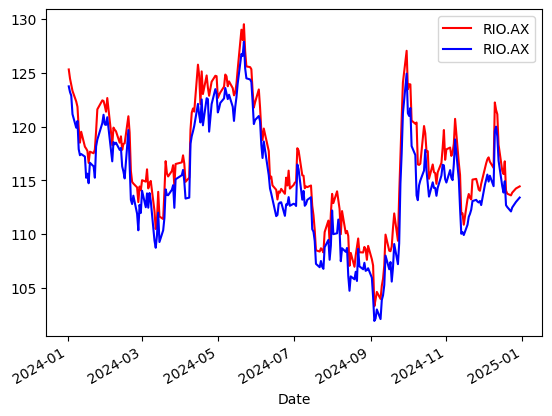

In [3]:
import matplotlib.pyplot as plt
#plot the low as blue and the high as red 
#('High', 'RIO.AX')
#('Low', 'RIO.AX')
fig, ax = plt.subplots()
df['High'].plot(color='red', label='High', ax=ax)
df['Low'].plot(color='blue', label='Low', ax=ax)
plt.legend()
plt.show()



In [4]:

# data.to_csv("RIO_2024_prices.csv")

# Print the first few rows to check
print(data.head())


Price            Close        High         Low        Open  Volume
Ticker          RIO.AX      RIO.AX      RIO.AX      RIO.AX  RIO.AX
Date                                                              
2024-01-02  125.172913  125.314976  123.743087  123.825587  432987
2024-01-03  123.477287  124.467160  123.211481  124.366340  687039
2024-01-04  123.275642  123.917223  122.876946  123.174822  984237
2024-01-05  121.314240  123.321481  121.158428  123.284811  682934
2024-01-08  120.544334  122.340760  119.902754  121.213410  785847
